In [25]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


ModuleNotFoundError: No module named 'sklearn'

In [8]:
df = pd.read_csv("education_dropout.csv")

In [9]:

# 2. Clean Column Names
df.columns = df.columns.str.strip()

# 3. Clean Categorical Data
df_obj = df.select_dtypes(['object'])
df[df_obj.columns] = df_obj.apply(lambda x: x.str.strip())

# 4. Fix Data Types
cols_to_fix = ['sat_score', 'current_gpa', 'attendance_rate']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 5. Handle Missing Values
for col in cols_to_fix:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# 6. Feature Selection
if 'student_id' in df.columns:
    df = df.drop(columns=['student_id'])

# 7. Final Inspection
print("Missing values per column:\n", df.isnull().sum())
print("\nData Preview:\n", df.head())

# 8. Save the Cleaned Data
df.to_csv('cleaned_education_dropout.csv', index=False)
print("\nData Wrangling complete. File saved as 'cleaned_education_dropout.csv'.")

C:\Users\KeerthanMuniRajaT\AppData\Local\Temp\ipykernel_12072\3891158236.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_obj = df.select_dtypes(['object'])


Missing values per column:
 age                                  0
gender                               0
first_generation_college             0
international_student                0
residency_status                     0
high_school_gpa                      0
sat_score                            0
act_score                            0
advanced_courses_taken               0
extracurricular_activities           0
major                                0
enrollment_status                    0
semester_credits                     0
admission_type                       0
starting_semester                    0
family_income                        0
financial_aid_received               0
pell_grant_eligible (scholarship)    0
student_loan_amount                  0
has_campus_job                       0
current_gpa                          0
credits_completed                    0
courses_failed                       0
courses_withdrawn                    0
attendance_rate                     

In [ ]:
# 1. Load Data
df = pd.read_csv('cleaned_education_dropout.csv')
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# 2. FEATURE EXTRACTION
# Composite risk and engagement metrics
df['total_academic_risk'] = df['courses_failed'] + df['courses_withdrawn']
df['engagement_score'] = df['tutoring_sessions_attended'] + df['library_visits_per_month'] + df['clubs_joined']
df['gpa_attendance_idx'] = df['current_gpa'] * (df['attendance_rate'] / 100)

# 3. FEATURE TRANSFORMATION
# Binary Mappings
binary_cols = ['first_generation_college', 'international_student', 'financial_aid_received', 
               'pell_grant_eligible (scholarship)', 'has_campus_job', 'has_disability']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# One-Hot Encoding for categories
multi_cat = ['gender', 'residency_status', 'major', 'enrollment_status', 
             'admission_type', 'starting_semester', 'family_income', 'living_arrangement']
df_transformed = pd.get_dummies(df, columns=multi_cat, drop_first=True)

# Encode Target (Dropout Status)
df_transformed['target'] = df_transformed['dropped_out'].map({'Yes': 1, 'No': 0})
df_transformed = df_transformed.drop(columns=['dropped_out', 'student_id'], errors='ignore')

# Scaling Numerical Features
num_features = df_transformed.select_dtypes(include=['number']).columns.drop('target')
scaler = StandardScaler()
df_transformed[num_features] = scaler.fit_transform(df_transformed[num_features])

# 4. FEATURE SELECTION (Using Random Forest)
X = df_transformed.drop(columns=['target'])
y = df_transformed['target']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Selection by Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
selected_features = importances[importances > 0.01].index.tolist()

# Save final feature set
final_data = df_transformed[selected_features + ['target']]
final_data.to_csv('final_features.csv', index=False)

print("Feature Engineering Complete.")
print(f"Top 5 Features: {selected_features[:5]}")

In [10]:

# 1. Load the cleaned data from the previous step
df = pd.read_csv("cleaned_education_dropout.csv")

# Set the visual style
sns.set(style="whitegrid")

C:\Users\KeerthanMuniRajaT\AppData\Local\Temp\ipykernel_12072\2042074210.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dropped_out', data=df, palette='viridis')


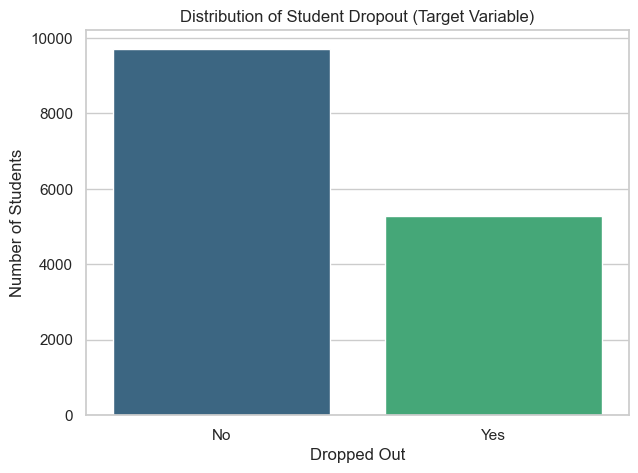

In [11]:
# 2. Target Variable Distribution (Class Balance)
plt.figure(figsize=(7, 5))
sns.countplot(x='dropped_out', data=df, palette='viridis')
plt.title('Distribution of Student Dropout (Target Variable)')
plt.xlabel('Dropped Out')
plt.ylabel('Number of Students')
plt.show()

C:\Users\KeerthanMuniRajaT\AppData\Local\Temp\ipykernel_12072\451161901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dropped_out', y='current_gpa', data=df, ax=axes[0], palette='Set2')
C:\Users\KeerthanMuniRajaT\AppData\Local\Temp\ipykernel_12072\451161901.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dropped_out', y='attendance_rate', data=df, ax=axes[1], palette='Set1')


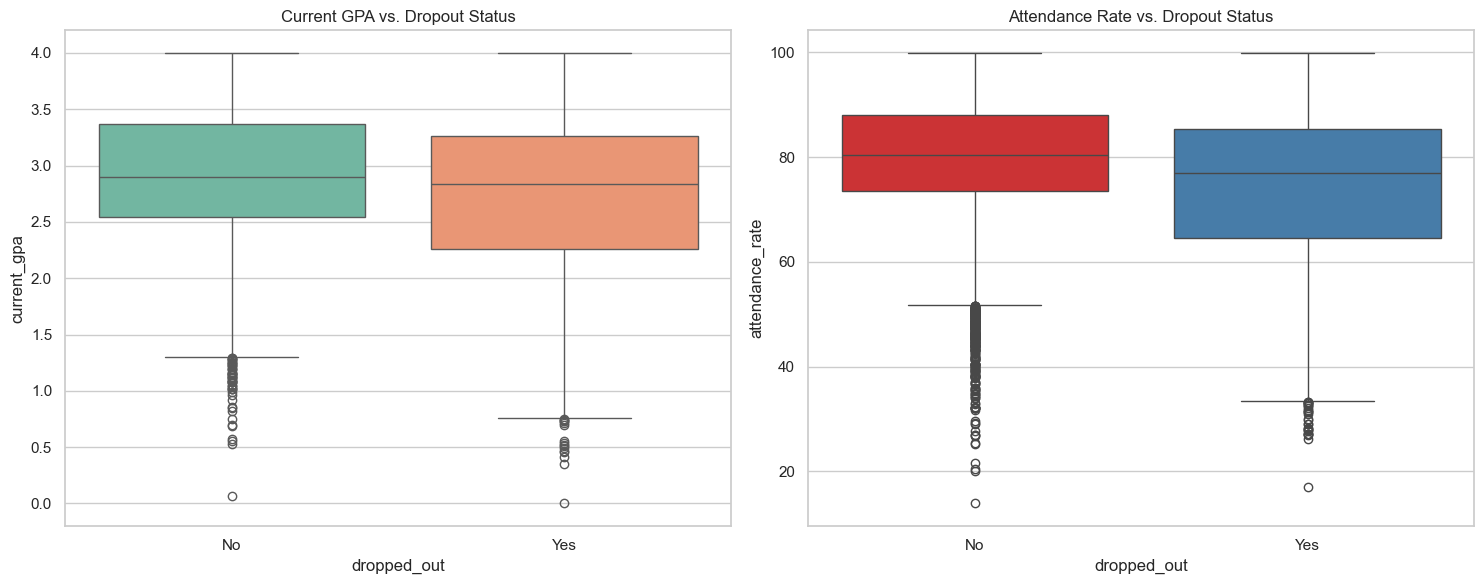

In [12]:
# 3. Numerical Features vs. Dropout (Boxplots)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x='dropped_out', y='current_gpa', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Current GPA vs. Dropout Status')

sns.boxplot(x='dropped_out', y='attendance_rate', data=df, ax=axes[1], palette='Set1')
axes[1].set_title('Attendance Rate vs. Dropout Status')

plt.tight_layout()
plt.show()

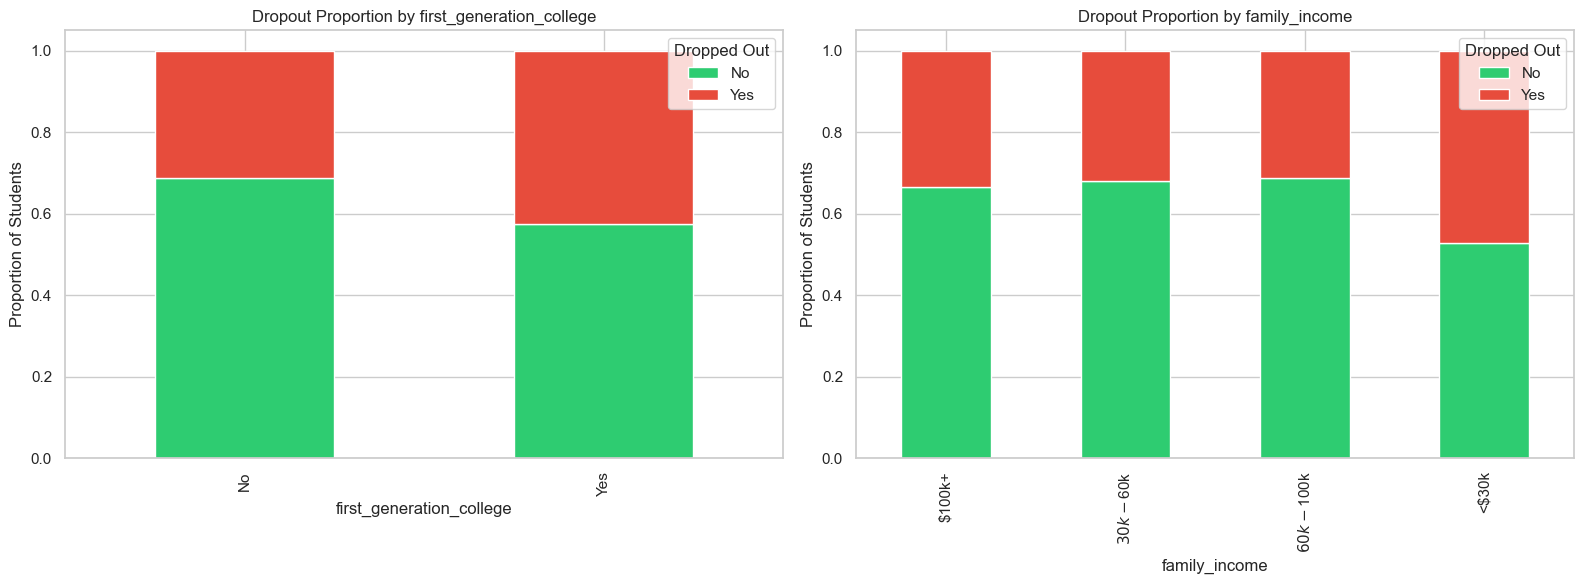

In [13]:
# 4. Categorical Features vs. Dropout (Stacked Bar Charts)
categorical_cols = ['first_generation_college', 'family_income']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(categorical_cols):
    # Create a cross-tabulation and normalize to show proportions
    prop_df = pd.crosstab(df[col], df['dropped_out'], normalize='index')
    prop_df.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'Dropout Proportion by {col}')
    axes[i].set_ylabel('Proportion of Students')
    axes[i].legend(title='Dropped Out', loc='upper right')

plt.tight_layout()
plt.show()

C:\Users\KeerthanMuniRajaT\AppData\Local\Temp\ipykernel_12072\1561245083.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dropped_out', y=var, data=df, palette='viridis')
C:\Users\KeerthanMuniRajaT\AppData\Local\Temp\ipykernel_12072\1561245083.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dropped_out', y=var, data=df, palette='viridis')
C:\Users\KeerthanMuniRajaT\AppData\Local\Temp\ipykernel_12072\1561245083.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dropped_out', y=var, data=df, palette='viridis')


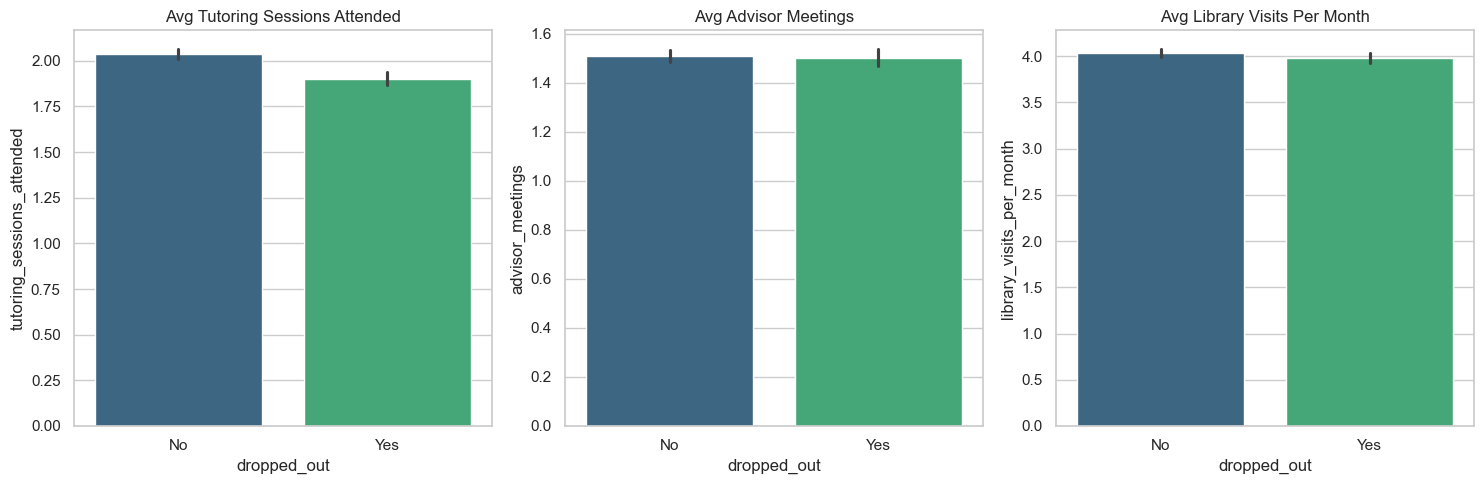

In [14]:
# Analyzing Engagement: Tutoring and Advisor Meetings
engagement_vars = ['tutoring_sessions_attended', 'advisor_meetings', 'library_visits_per_month']

plt.figure(figsize=(15, 5))
for i, var in enumerate(engagement_vars):
    plt.subplot(1, 3, i+1)
    sns.barplot(x='dropped_out', y=var, data=df, palette='viridis')
    plt.title(f'Avg {var.replace("_", " ").title()}')

plt.tight_layout()
plt.show()

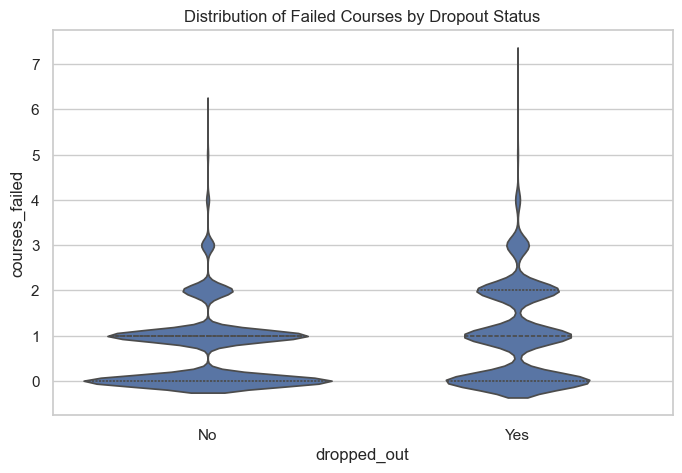

In [15]:
# Comparing Course Failures vs. Dropout
plt.figure(figsize=(8, 5))
sns.violinplot(x='dropped_out', y='courses_failed', data=df, inner="quart")
plt.title('Distribution of Failed Courses by Dropout Status')
plt.show()

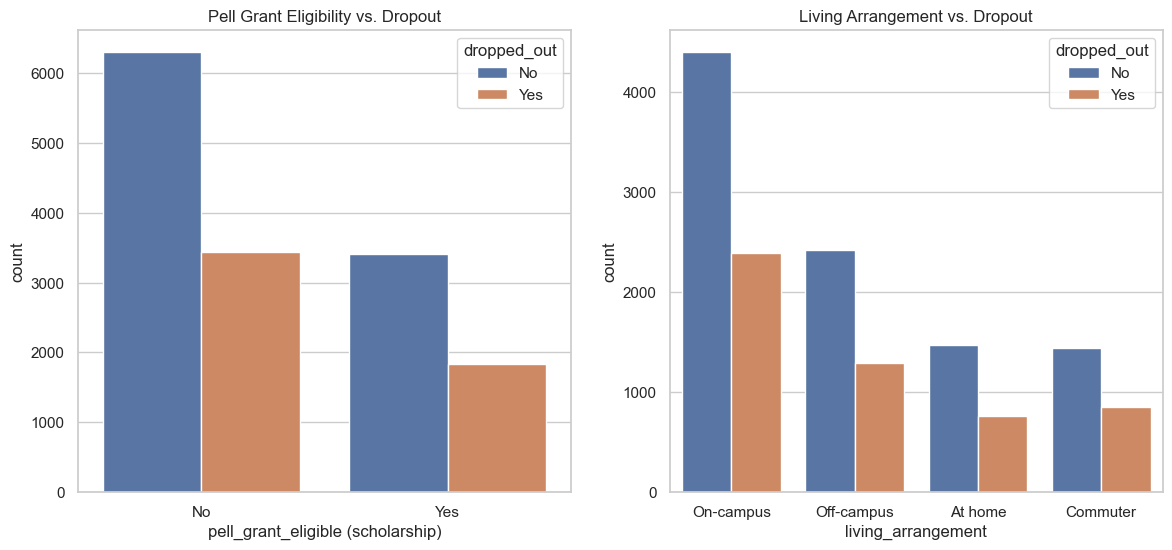

In [16]:
# Impact of Financial Aid and Living Arrangement
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pell Grant Eligibility
sns.countplot(x='pell_grant_eligible (scholarship)', hue='dropped_out', data=df, ax=axes[0])
axes[0].set_title('Pell Grant Eligibility vs. Dropout')

# Living Arrangement
sns.countplot(x='living_arrangement', hue='dropped_out', data=df, ax=axes[1])
axes[1].set_title('Living Arrangement vs. Dropout')

plt.show()

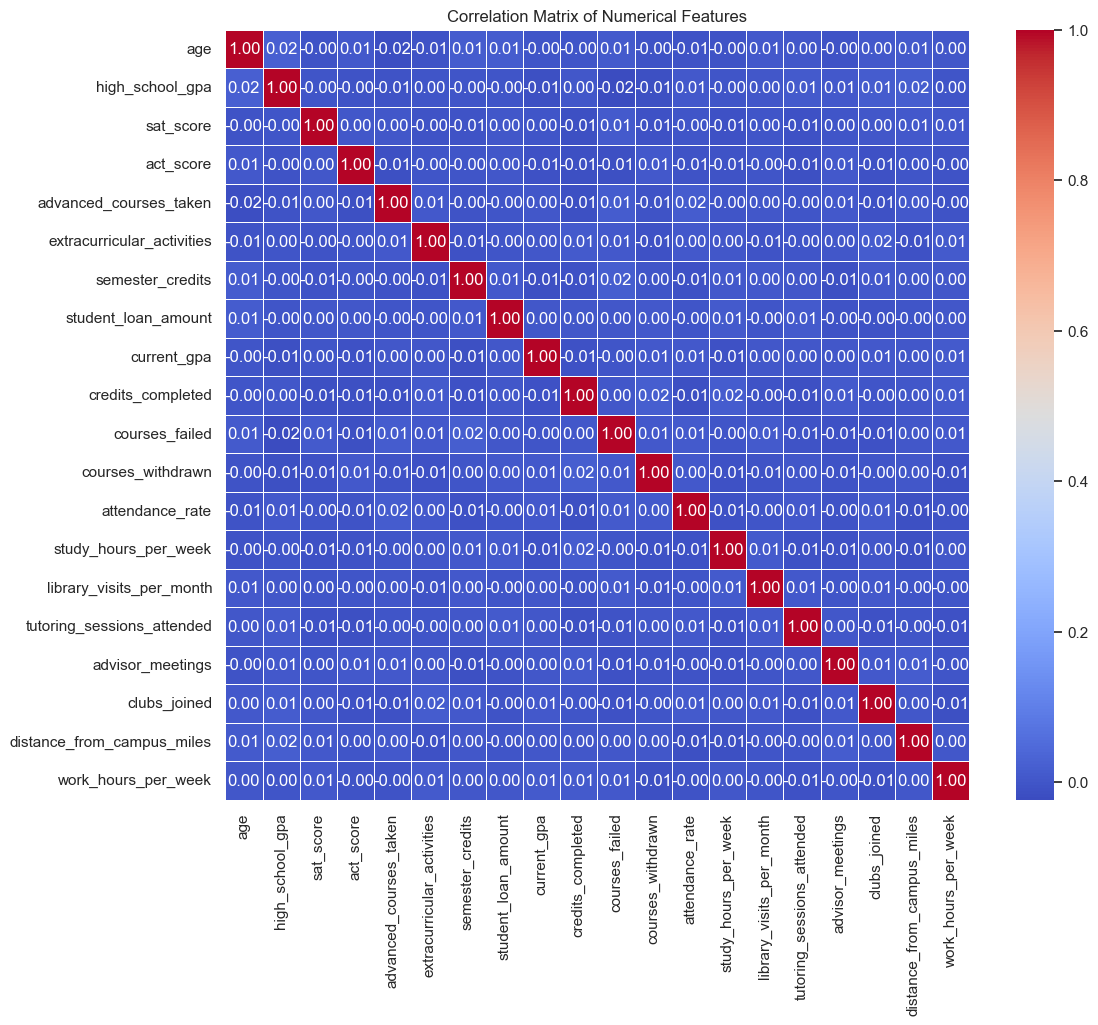

In [17]:
# 5. Correlation Heatmap
numerical_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 10))
corr = numerical_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [18]:
# Hypothesis Testing (Questions)

# 1. Is the average Current GPA of students who drop out significantly lower than those who stay?

# 2. Do students who drop out have a significantly lower Attendance Rate than those who complete their studies?

# 3.Is a student’s First-Generation status (Yes/No) significantly linked to their likelihood of dropping out?

# 4. Financial stress is a major reason for leaving school early.

# 5. Does the number of Semester Credits a student takes (overloading vs. underloading) impact the dropout rate?

# 6. Is there a significant difference in the number of Courses Failed between the two groups?

# 7. Do students who drop out attend significantly fewer Advisor Meetings?

# 8. Do students who Work more hours per week have a higher probability of dropping out?

# 9. Does the Distance from Campus (miles) significantly affect the dropout rate?

# 10. Is the High School GPA a significant predictor of university dropout?

In [19]:
from scipy import stats

# 1. Load data
df = pd.read_csv('cleaned_education_dropout.csv')

# Pre-cleaning: ensure target column is clean and numeric columns are ready
df['dropped_out'] = df['dropped_out'].str.strip()

def run_test(q_num, feature, test_type, h0_desc):
    print(f"--- Hypothesis Test {q_num}: {feature} ---")
    print(f"Null Hypothesis (H0): {h0_desc}")
    
    if test_type == 'numeric':
        # Split groups and remove NaNs for accurate testing
        group_yes = df[df['dropped_out'] == 'Yes'][feature].dropna()
        group_no = df[df['dropped_out'] == 'No'][feature].dropna()
        t_stat, p_val = stats.ttest_ind(group_yes, group_no)
        print(f"Test: Independent Samples T-test | P-Value: {p_val:.4e}")
    else:
        # Cross-tabulate for Chi-Square
        contingency = pd.crosstab(df[feature], df['dropped_out'])
        chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
        print(f"Test: Chi-Square Test of Independence | P-Value: {p_val:.4e}")
    
    if p_val < 0.05:
        print("RESULT: Statistically Significant. We reject H0.\n")
    else:
        print("RESULT: Not Significant. We fail to reject H0.\n")
        
run_test(1, 'current_gpa', 'numeric', "Mean GPA is the same for both groups.")
run_test(2, 'attendance_rate', 'numeric', "Mean Attendance is the same for both groups.")
run_test(3, 'first_generation_college', 'categorical', "First-gen status is independent of dropout status.")
run_test(4, 'family_income', 'categorical', "Family income bracket does not affect dropout risk.")
run_test(5, 'courses_failed', 'numeric', "Number of courses failed does not differ between groups.")
run_test(6, 'gender', 'categorical', "Gender has no relationship with dropping out.")
run_test(7, 'financial_aid_received', 'categorical', "Financial aid does not influence retention.")
run_test(8, 'student_loan_amount', 'numeric', "Mean debt is equal between dropouts and those who stay.")
run_test(9, 'enrollment_status', 'categorical', "Full-time/Part-time status doesn't impact dropout rates.")
run_test(10, 'major', 'categorical', "Student's major is independent of dropout risk.")

--- Hypothesis Test 1: current_gpa ---
Null Hypothesis (H0): Mean GPA is the same for both groups.
Test: Independent Samples T-test | P-Value: 1.5287e-60
RESULT: Statistically Significant. We reject H0.

--- Hypothesis Test 2: attendance_rate ---
Null Hypothesis (H0): Mean Attendance is the same for both groups.
Test: Independent Samples T-test | P-Value: 5.1650e-127
RESULT: Statistically Significant. We reject H0.

--- Hypothesis Test 3: first_generation_college ---
Null Hypothesis (H0): First-gen status is independent of dropout status.
Test: Chi-Square Test of Independence | P-Value: 4.3020e-43
RESULT: Statistically Significant. We reject H0.

--- Hypothesis Test 4: family_income ---
Null Hypothesis (H0): Family income bracket does not affect dropout risk.
Test: Chi-Square Test of Independence | P-Value: 2.3488e-52
RESULT: Statistically Significant. We reject H0.

--- Hypothesis Test 5: courses_failed ---
Null Hypothesis (H0): Number of courses failed does not differ between groups.